In [2]:
from qutip import *
import matplotlib.pyplot as plt
import numpy as np

In [3]:
plt.rcParams.update({
    # LaTeX rendering and font configuration
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"], 
    "font.size": 18,  

    "axes.titlesize": 18,        # Axis title
    "axes.labelsize": 18,         # Axis labels
    "xtick.labelsize": 18,        # X-ticks
    "ytick.labelsize": 18,        # Y-ticks
    "legend.fontsize": 16,        # Legend
    "figure.titlesize": 24,       # Figure title
    
    # LaTeX preamble packages
    "text.latex.preamble": r"""
        \usepackage{amsmath}
        \usepackage{amsfonts}
        \usepackage{amssymb}
        \usepackage{lmodern}
        \usepackage{mathpazo}
    """
})

In [ ]:
# Set the system parameters
N = 5

In [ ]:
def build_hamiltonian(N, omega0, V):

    

    sz_list = []
    for i in range(N):
        op_list = [qeye(2)] * N
        op_list[i] = sigmaz()
        sz_list.append(tensor(op_list))
    

    H = 0

    for i in range(N):
        H += 0.5 * omega0 * sz_list[i]
    

    for i in range(N):
        for j in range(i+1, N):
            H += -0.25 * V / N * sz_list[i] * sz_list[j]  
    
    return H, sz_list

def calculate_magnetization(N, omega0_vals, V_vals):

    magnetization = np.zeros((len(omega0_vals), len(V_vals)))
    
    for i, omega0 in enumerate(omega0_vals):
        for j, V in enumerate(V_vals):
            H, sz_list = build_hamiltonian(N, omega0, V)
            

            energies, states = H.eigenstates()
            ground_state = states[0]
            

            total_mz = 0
            for sz_op in sz_list:
                total_mz += expect(sz_op, ground_state)
            
            magnetization[i, j] = total_mz / N  
    
    return magnetization


In [106]:
omega0_vals = np.linspace(-1, 1, 100)
V_vals = np.linspace(-2, 2, 100)
magnetization = np.zeros((len(omega0_vals), len(V_vals)))
for i,omega0 in enumerate(omega0_vals):
    for j,V in enumerate(V_vals):
        H, sz_list = build_hamiltonian(N, omega0, V)
        energies, states = H.eigenstates()
        ground_state = states[0]
        
        total_mz = sum([expect(sz_op, ground_state) for sz_op in sz_list])
        magnetization[i, j] = (total_mz / N)

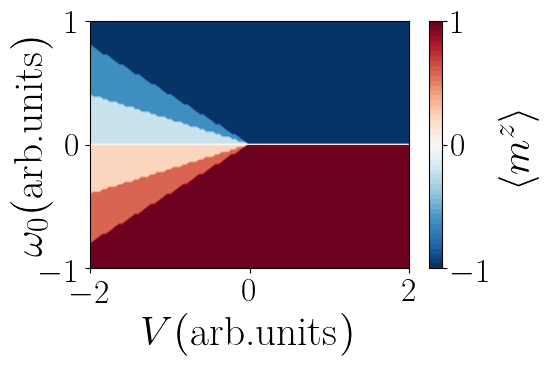

In [ ]:
V_grid, omega0_grid = np.meshgrid(V_vals, omega0_vals)

plt.figure(figsize=(6, 4))
contour = plt.contourf(V_grid, omega0_grid, magnetization, levels=50, cmap='RdBu_r')
cbar=plt.colorbar(contour, label=r'$\langle m^z \rangle$', ticks=[-1,0,1])
plt.xlabel(r'$V (\mathrm{arb.units})$')
plt.ylabel(r'$\omega_0 (\mathrm{arb.units})$', labelpad=-10)
plt.tight_layout()
plt.show()

plt.savefig("Ising_transition")

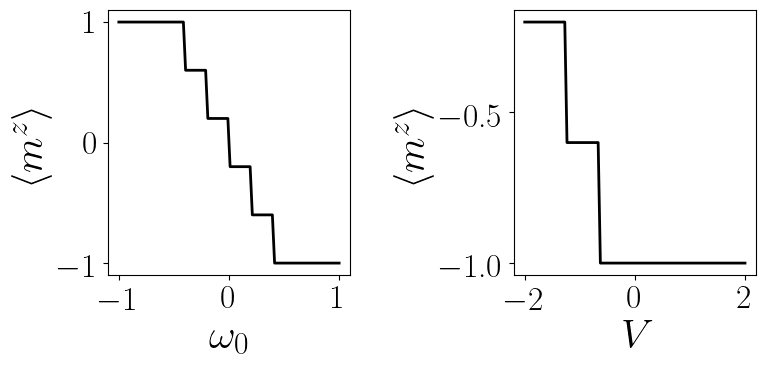

In [122]:
# Plot specific cross-sections
plt.figure(figsize=(8, 4))

# Cross-section 1: Fixed V = 1.0 (ferromagnetic case)
plt.subplot(1, 2, 1)
V_fixed = -1.0
idx_V = np.argmin(np.abs(V_vals - V_fixed))
plt.plot(omega0_vals, magnetization[:, idx_V], 'k-', linewidth=2)
# plt.axvline(x=V_fixed, color='r', linestyle='--', alpha=0.7)
# plt.axvline(x=-V_fixed, color='r', linestyle='--', alpha=0.7)
plt.xlabel(r'$\omega_0$')
plt.ylabel(r'$\langle m^z \rangle$')



# Cross-section 2: Fixed omega0 = 0 (symmetric case)
plt.subplot(1, 2, 2)
omega0_fixed = 0.25
idx_omega0 = np.argmin(np.abs(omega0_vals - omega0_fixed))
plt.plot(V_vals, magnetization[idx_omega0, :], 'k-', linewidth=2)
plt.xlabel(r'$V$')
plt.ylabel(r'$\langle m^z \rangle$')

plt.tight_layout()

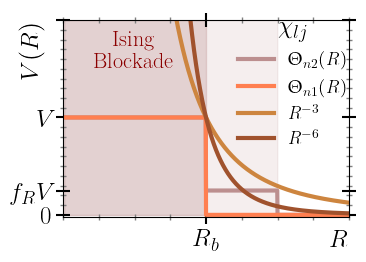

In [7]:
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

colors = ['lightsteelblue', 'royalblue', 'cornflowerblue', 'slateblue', 'midnightblue']
clist = ['rosybrown', 'coral', 'peru',  'sienna']


x = np.linspace(0.01,2, 1000)
V=10;

def theta(xi, V):
    return np.where(xi > 1, 0, V)

def theta2(xi, V):
    NN = V/4
    return np.where(xi > 1.5, 0, np.where(xi > 1, NN, V))

fig, ax = plt.subplots(figsize=(4,3))
ax.tick_params(which='both', direction='inout', 
                top=True, right=True, bottom=True, left=True)

ax.minorticks_on()
ax.tick_params(axis='both', which='major', 
                length=10, width=1.5, colors='black')
ax.tick_params(axis='both', which='minor', 
                length=5, width=1, colors='gray')

ax.xaxis.set_major_locator(MultipleLocator(1.0))  
ax.xaxis.set_minor_locator(MultipleLocator(0.25)) 

ax.yaxis.set_major_locator(MultipleLocator(5))  
ax.yaxis.set_minor_locator(MultipleLocator(1))  

ax.fill_between(x, 0, 20, where=(x<=1), color=clist[0], alpha=0.3)
ax.fill_between(x, 0, 20, where=(x<=1.5), color=clist[0], alpha=0.15)
ax.plot(x, theta2(x,V), label=r'$\Theta_{n2}(R)$', lw=3, color=clist[0])
ax.plot(x, theta(x,V), label=r'$\Theta_{n1}(R)$', lw=3, color=clist[1])
ax.plot(x, V*1/(x*x*x), label=r'$R^{-3}$', lw=3, color=clist[2])
ax.plot(x, V*1/(x*x*x*x*x*x), label=r'$R^{-6}$', lw=3, color=clist[3])
ax.set_ylim(-0.25,20)
ax.set_xlim(0,2)
ax.set_xticks([1], [r'$R_b$'])
ax.set_yticks([0,2.5, 10,20], ['0', r'$f_RV$', r'$V$',''])
ax.set_xlabel(r'$R$', labelpad=-15, loc='right')
ax.set_ylabel(r'$V(R)$',labelpad=-25, loc='top')
plt.legend(loc='upper right', fontsize=13, title=r'$\chi_{lj}$', frameon=False,bbox_to_anchor=(1.05, 1.10))
plt.text(0.5, 15, 'Ising\nBlockade', color='darkred', fontsize=16, ha='center')
plt.tight_layout()
# plt.savefig("interaction_kernel.pdf", dpi=300)

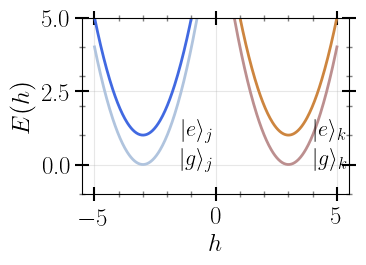

In [ ]:
x = np.linspace(-5, 5, 400)
colors = ['lightsteelblue', 'royalblue', 'rosybrown',  'peru' ]
shift = 3.0

g1 =  1.0 * (x+shift)**2
g2 =  1.0 * (x-shift)**2



energy_gap = 1.0 
e1 = 1.0 * (x+shift)**2 + energy_gap 
e2 = 1.0 * (x-shift)**2 + energy_gap 

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(x, g1, colors[0], linewidth=2)
ax.plot(x, e1, colors[1], linewidth=2)
ax.plot(x, g2, colors[2], linewidth=2)
ax.plot(x, e2, colors[3], linewidth=2)

ax.tick_params(which='both', direction='inout', 
                top=True, right=True, bottom=True, left=True)

ax.minorticks_on()
ax.tick_params(axis='both', which='major', 
                length=10, width=1.5, colors='black')
ax.tick_params(axis='both', which='minor', 
                length=5, width=1, colors='gray')

ax.xaxis.set_major_locator(MultipleLocator(5.0))  
ax.xaxis.set_minor_locator(MultipleLocator(1)) 

ax.yaxis.set_major_locator(MultipleLocator(2.5))  
ax.yaxis.set_minor_locator(MultipleLocator(1))  

# Customize the plot
plt.xlabel(r'$h$')
plt.ylabel(r'$E(h)$')
plt.grid(True, alpha=0.3)
# plt.legend(fontsize=12)
plt.ylim(-1, energy_gap + 4)  # Adjust y-axis limits for better visualization


plt.text(-0.75, 1.0, r'$|e\rangle_j$', color='k', fontsize=16, ha='center')
plt.text(-0.75, 0.0, r'$|g\rangle_j$', color='k', fontsize=16, ha='center')

plt.text(4.25, 1.0, r'$|e\rangle_k$', color='k', fontsize=16, ha='center')
plt.text(4.25, 0.0, r'$|g\rangle_k$', color='k', fontsize=16, ha='center')


# Show the plot
plt.tight_layout()

In [ ]:

Rb = 1.0
def chi_tilde(q):
    return 2*np.sin(q*Rb)/q if np.abs(q)>1e-12 else 2*Rb
qs = np.linspace(-10,10,2001)
vals = np.array([chi_tilde(q) for q in qs])
kc = 2*np.pi/2.0


fig, ax = plt.subplots(figsize=(4, 2.6))
plt.plot(qs, np.abs(vals), label=r'$|\tilde{\chi}(q)|$', color='royalblue', lw=2)
plt.axvline(x=kc, color='darkred', linestyle='-', label=r'$\pm k_c$', lw=2)
plt.axvline(x=-kc, color='darkred', linestyle='-', lw=2)
plt.xlabel(r'$q$')
plt.ylabel(r'$|\tilde{\chi}(q)|$')
ax.set_xticks([-kc,  kc], [r'$-k_c$',  r'$k_c$'])
ax.set_yticks([0, Rb, 2*Rb], ['0', r'$R_b$', r'$2R_b$'])
plt.legend(fontsize=12, frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

NameError: name 'np' is not defined

: 

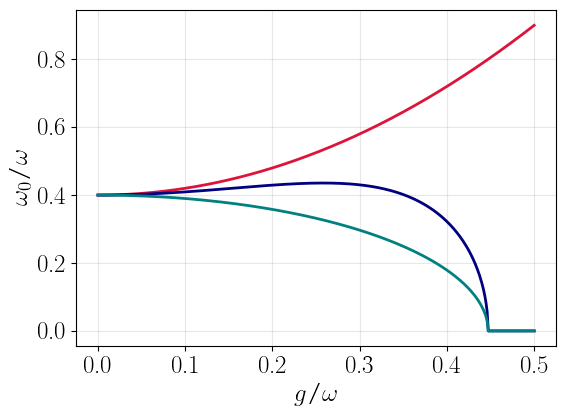

In [207]:
import numpy as np
import matplotlib.pyplot as plt


omega = 1.0         # cavity frequency 
J = 0.2 * omega      # nearest-neighbour coupling 
g_min, g_max = 0.0, 0.5
ng = 400
g_vals = np.linspace(g_min, g_max, ng)

# Boundary functions
def eps_c1(g, J, omega):
    return 2.0 * (J + (g**2) / omega)

def eps_c2(g, J, omega):
    arg = 1.0 - (g**2) / (omega * J)
    arg = np.maximum(arg, 0.0)   # guard against tiny negative numerical noise
    return 2.0 * (J + (g**2) / omega) * np.sqrt(arg)

def eps_c3(g, J, omega):
    arg = 1.0 - (g**2) / (omega * J)
    arg = np.maximum(arg, 0.0)
    return 2.0 * J * np.sqrt(arg)


eps1 = eps_c1(g_vals, J, omega)
eps2 = eps_c2(g_vals, J, omega)
eps3 = eps_c3(g_vals, J, omega)


plt.figure(figsize=(6.0,4.5))
plt.plot(g_vals/omega, eps1/omega, lw=2, color='crimson')
plt.plot(g_vals/omega, eps2/omega, lw=2, color='navy')
plt.plot(g_vals/omega, eps3/omega, lw=2, color='teal')


plt.xlabel(r'$g/\omega$')
plt.ylabel(r'$\omega_0/\omega$')
# plt.legend(loc='best', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
